
1.1 Write Down the Model

CR3BP equations in rotating frame 
Jacobi constant CC 
Zero‑velocity curves (ZVCs) 
Deliverable

Clean derivation section (no code yet) 
Sketch of Hill’s regions vs CC 


In [28]:
# constants

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy

G = 1.0             # Gravitational constant (normalized)
M1 = 5.972e24       # Mass of Earth (primary)
M2 = 7.348e22       # Mass of Moon (secondary)
M3 = 1e-20          # Mass of tertiary (small asteroid)
omega = 1.0         # Angular velocity magnitude (normalized)
Omega = np.array([0, 0, 1]) * omega  # Angular velocity of the rotating frame
mu = M2 / (M1 + M2)
pos_earth = -mu * np.array([1, 0, 0])  # Earth at (mu, 0, 0)
pos_moon = (1 - mu) * np.array([1, 0, 0])
L1_x = 1 - (mu / 3)**(1/3)
L2_x = 1 + (mu / 3)**(1/3)
hill_radius = (mu / 3)**(1/3)



In [30]:
# common methods

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy

def calc_com(masses, pos):
    M = np.sum(masses)
    com = np.sum(pos * masses[:, None], axis=0) / M
    return com

def effective_potential(G, mu, pos_earth, pos_moon, pos_particle):
    r1 = np.linalg.norm(pos_particle - pos_earth)  # Distance to Earth
    r2 = np.linalg.norm(pos_particle - pos_moon)   # Distance to Moon
    potential = G * (1 - mu) / r1 + G * mu / r2 + 0.5 * np.linalg.norm(pos_particle[0:2])**2
    return potential

def calc_Jacobi_constant(state, mu):
    U = effective_potential(G, mu, pos_earth, pos_moon, state[:3])
    v_squared = np.linalg.norm(state[3:])**2
    jacobi = 2*U - v_squared
    return jacobi

def equations_of_motion(t, state, mu, masses):
    x, y, z, vx, vy, vz = state
    xdot  = vx
    ydot  = vy
    zdot  = vz

    r1 = np.sqrt((x+mu)**2 + y**2 + z**2)
    r2 = np.sqrt((x-1+mu)**2 + y**2 + z**2)

    vxdot = 2*vy + x - (1-mu)*(x+mu)/r1**3 - mu*(x-1+mu)/r2**3
    vydot = -2*vx + y - (1-mu)*y/r1**3 - mu*y/r2**3
    vzdot = -(1-mu)*z/r1**3 - mu*z/r2**3
    return [xdot, ydot, zdot, vxdot, vydot, vzdot]

def integrate_orbits(mu, masses, initial_state, t_span, dt):
    t_eval = np.linspace(t_span[0], t_span[1], int(round((t_span[1] - t_span[0]) / dt)) + 1)
    
    sol = solve_ivp(
        fun=equations_of_motion,
        t_span=t_span,
        y0=initial_state,
        args=(mu, masses),
        t_eval=t_eval,
        method='DOP853',
        rtol=1e-10,
        atol=1e-12
    )
    return sol.t, sol.y[0], sol.y[1], sol.y[2], sol.y[3], sol.y[4], sol.y[5]

def trajectory_analysis(mu, masses, initial_state, t_span, dt):
    t, x, y, z, vx, vy, vz = integrate_orbits(mu, masses, initial_state, t_span, dt)
    jacobi_constants = np.array([calc_Jacobi_constant(state, mu) for state in zip(x, y, z, vx, vy, vz)])
    return t, x, y, z, vx, vy, vz, jacobi_constants

def find_zero_velocity_curve(mu, jacobi_constant, x_range):
    y_values = []
    for x in x_range:
        pos_particle = np.array([x, 0, 0])
        U = effective_potential(G, mu, pos_earth, pos_moon, pos_particle)
        if 2*U - jacobi_constant >= 0:
            y_values.append(np.sqrt(2*U - jacobi_constant))
        else:
            y_values.append(np.nan)  # No real solution for y
    return np.array(y_values)
 
# Inside the Moon's Hill sphere: r2<rH≈(μ3)1/3r2 <rH ≈(3μ )1/3
# Negative Kepler energy w.r.t. the Moon: E2=12∣vrel∣2−μr2<0E2 =21 ∣vrel ∣2−r2 μ <0
def is_captured(state, mu, hill_radius):
    """Check if particle is temporarily captured by the Moon."""
    x, y, z, vx, vy, vz = state
    # Moon position in rotating frame
    x_moon = 1 - mu
    
    # Distance to Moon
    r2 = np.sqrt((x - x_moon)**2 + y**2 + z**2)
    
    # Kepler energy relative to the Moon
    v_rel_sq = vx**2 + vy**2 + vz**2
    E2 = 0.5 * v_rel_sq - mu / r2
    
    return (r2 < hill_radius) and (E2 < 0)

# plot hills region vs jaobi constant for captured trajectories
'''plt.figure(figsize=(10, 6))
x_range = np.linspace(-0.5, 1.5, 1000)
for initial_state, jacobi in captured_traj:
    y_zero_velocity = find_zero_velocity_curve(mu, jacobi, x_range)
    plt.plot(x_range, y_zero_velocity, label=f'Jacobi={jacobi:.4f}')
plt.title('Zero-Velocity Curves for Captured Trajectories')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 0.5)
plt.grid()
plt.legend()
plt.show()
'''

"plt.figure(figsize=(10, 6))\nx_range = np.linspace(-0.5, 1.5, 1000)\nfor initial_state, jacobi in captured_traj:\n    y_zero_velocity = find_zero_velocity_curve(mu, jacobi, x_range)\n    plt.plot(x_range, y_zero_velocity, label=f'Jacobi={jacobi:.4f}')\nplt.title('Zero-Velocity Curves for Captured Trajectories')\nplt.xlabel('x')\nplt.ylabel('y')\nplt.xlim(-0.5, 1.5)\nplt.ylim(-0.5, 0.5)\nplt.grid()\nplt.legend()\nplt.show()\n"

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


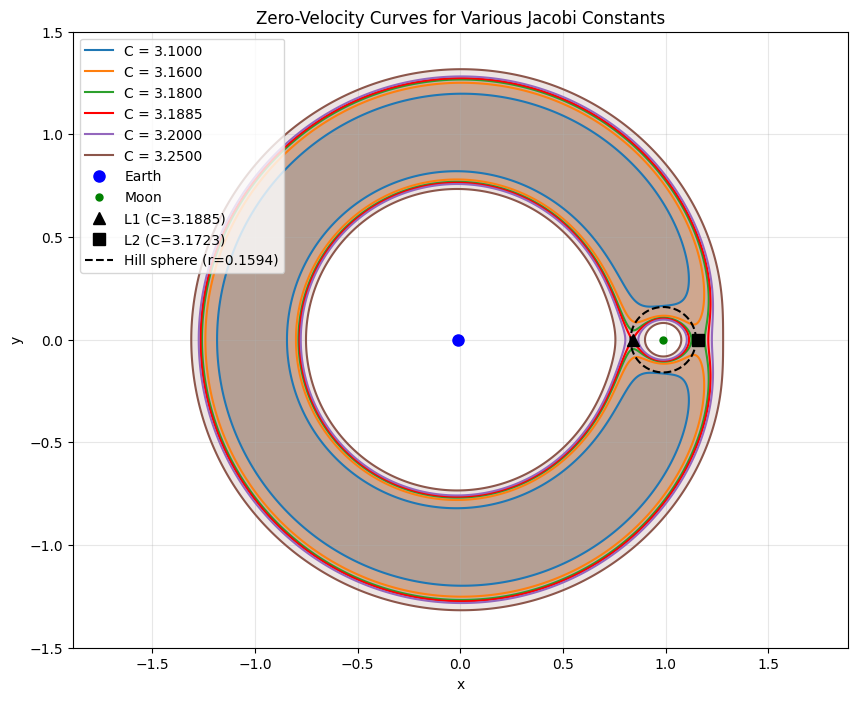

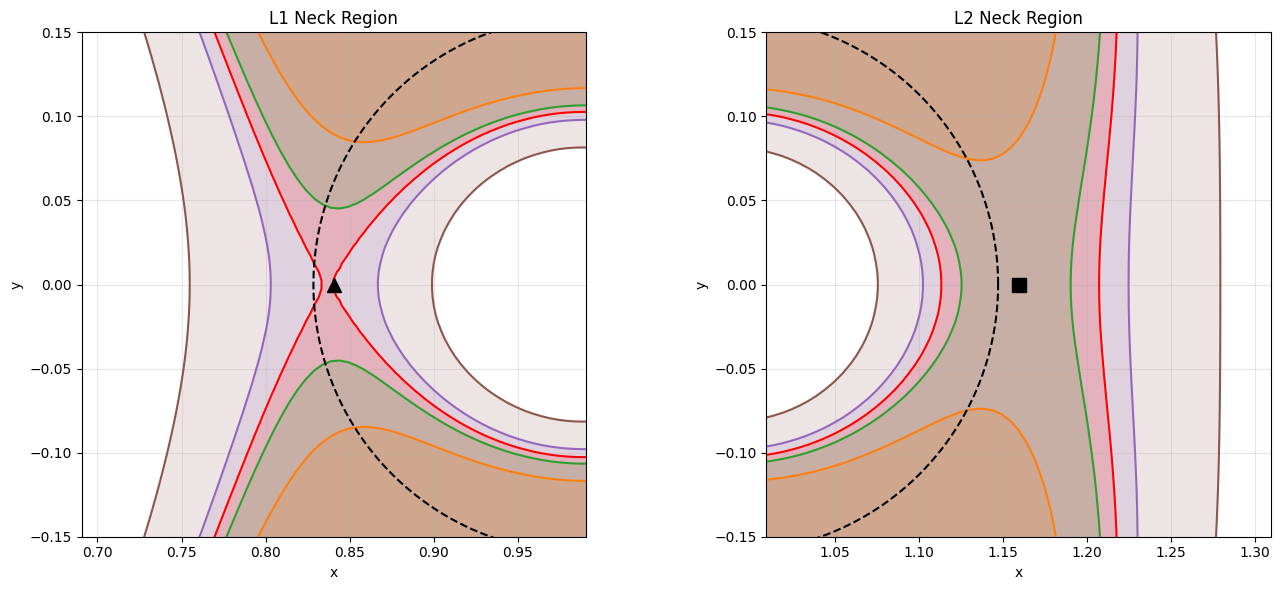

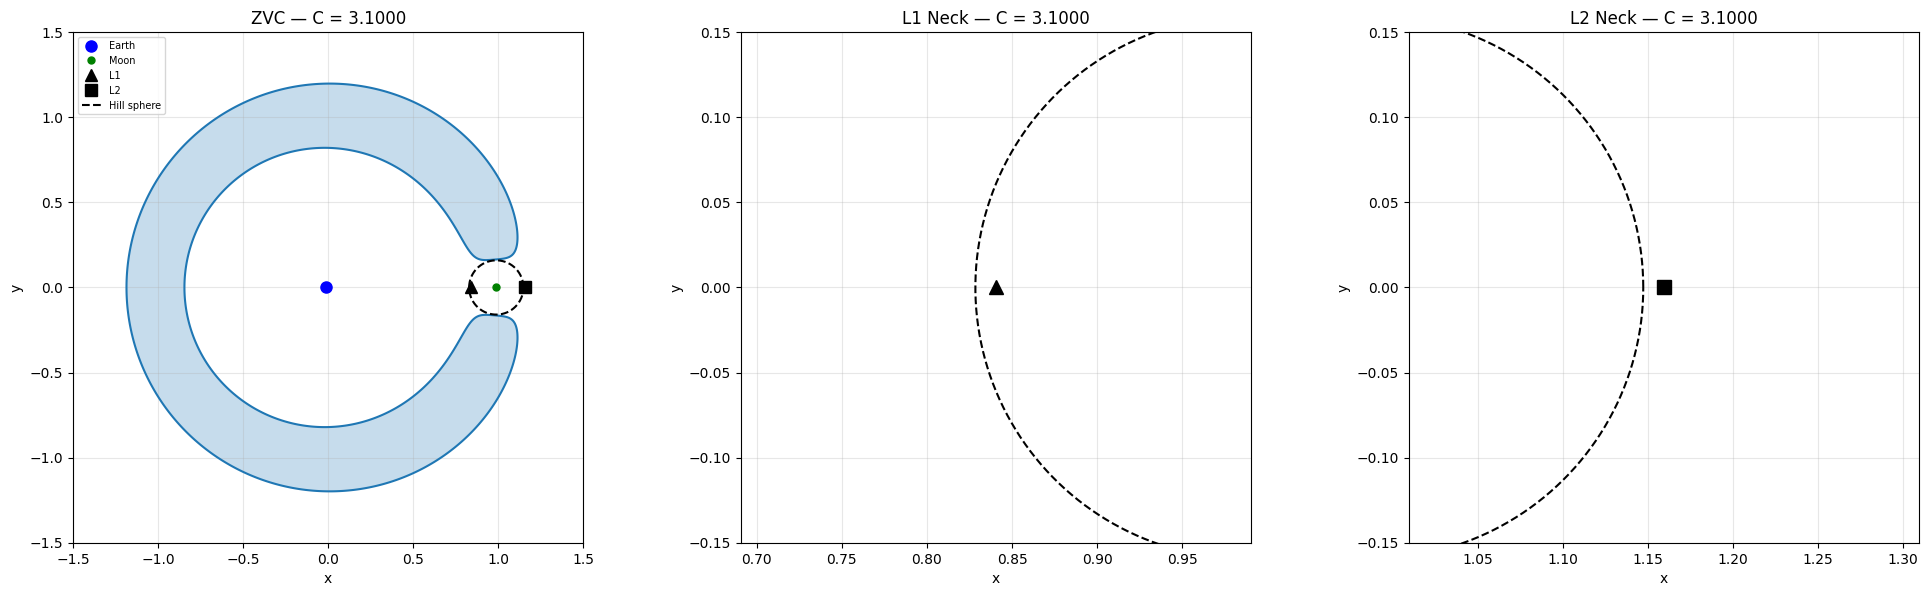

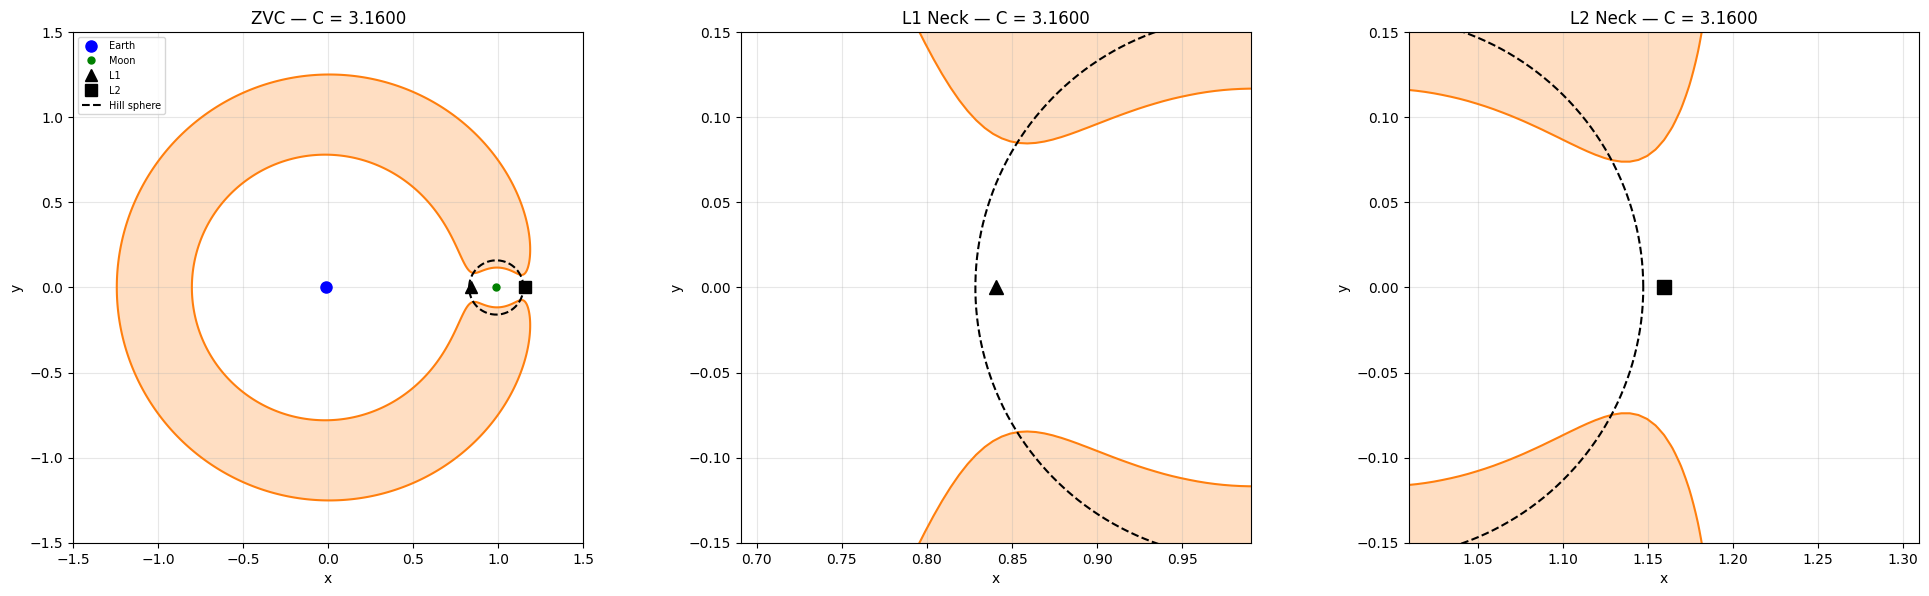

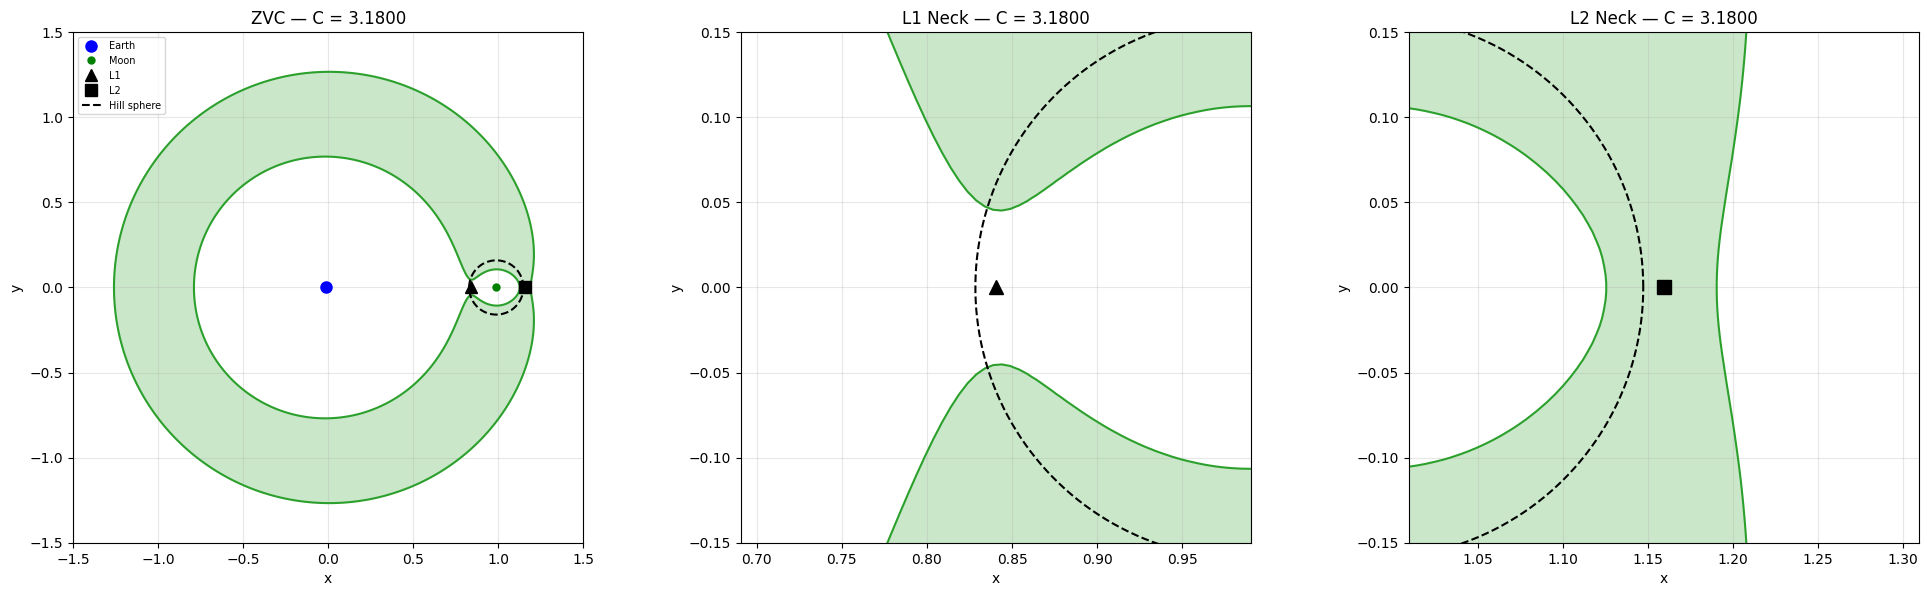

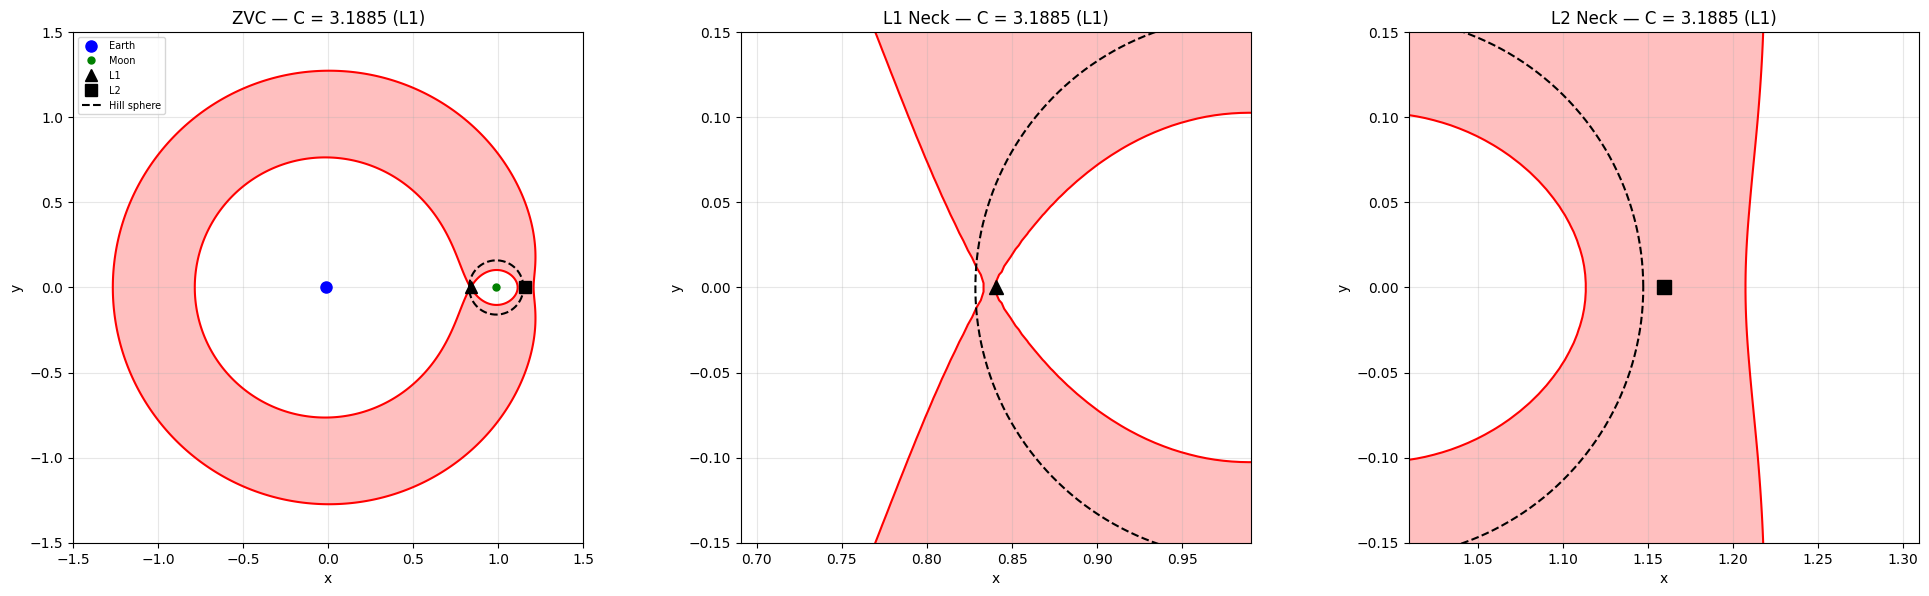

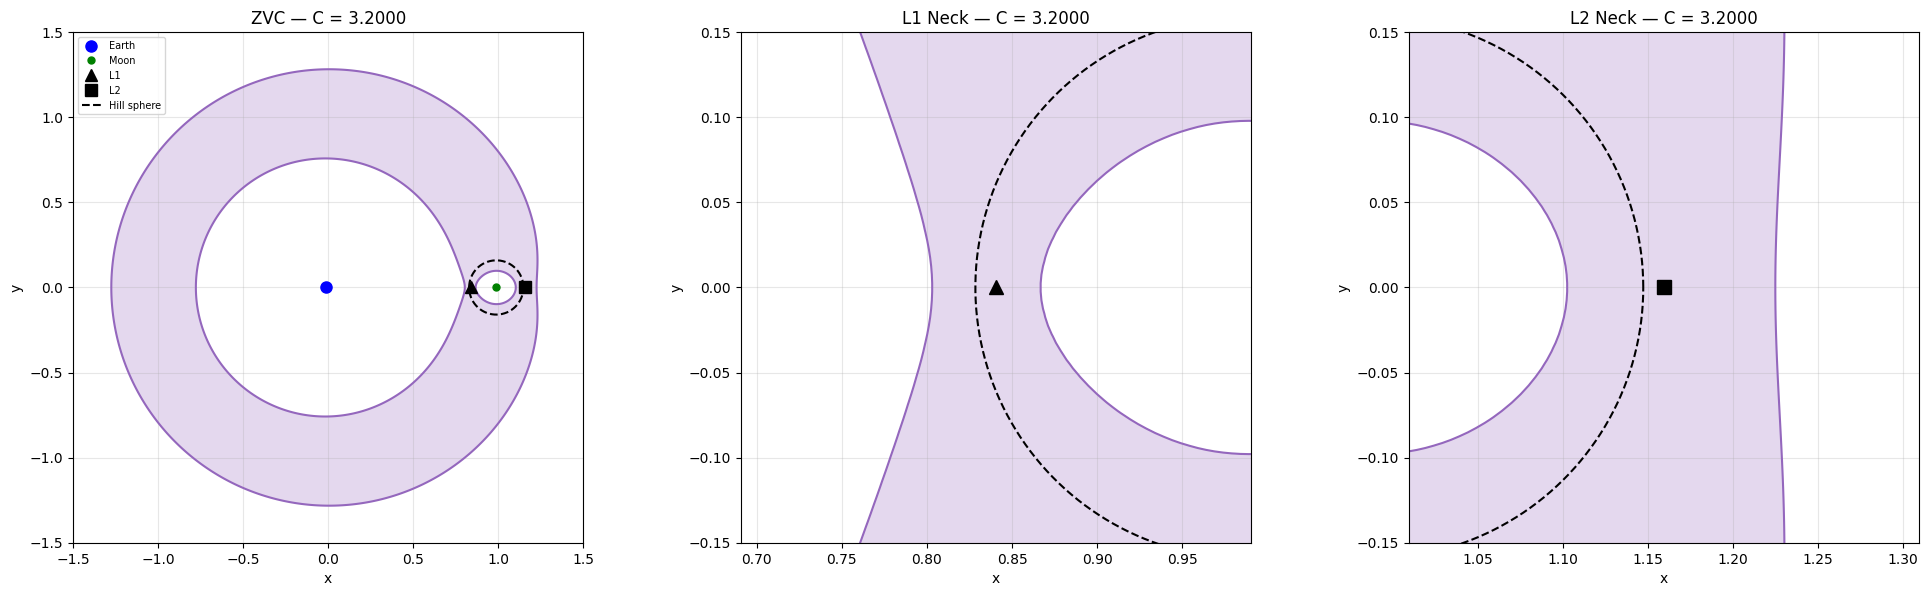

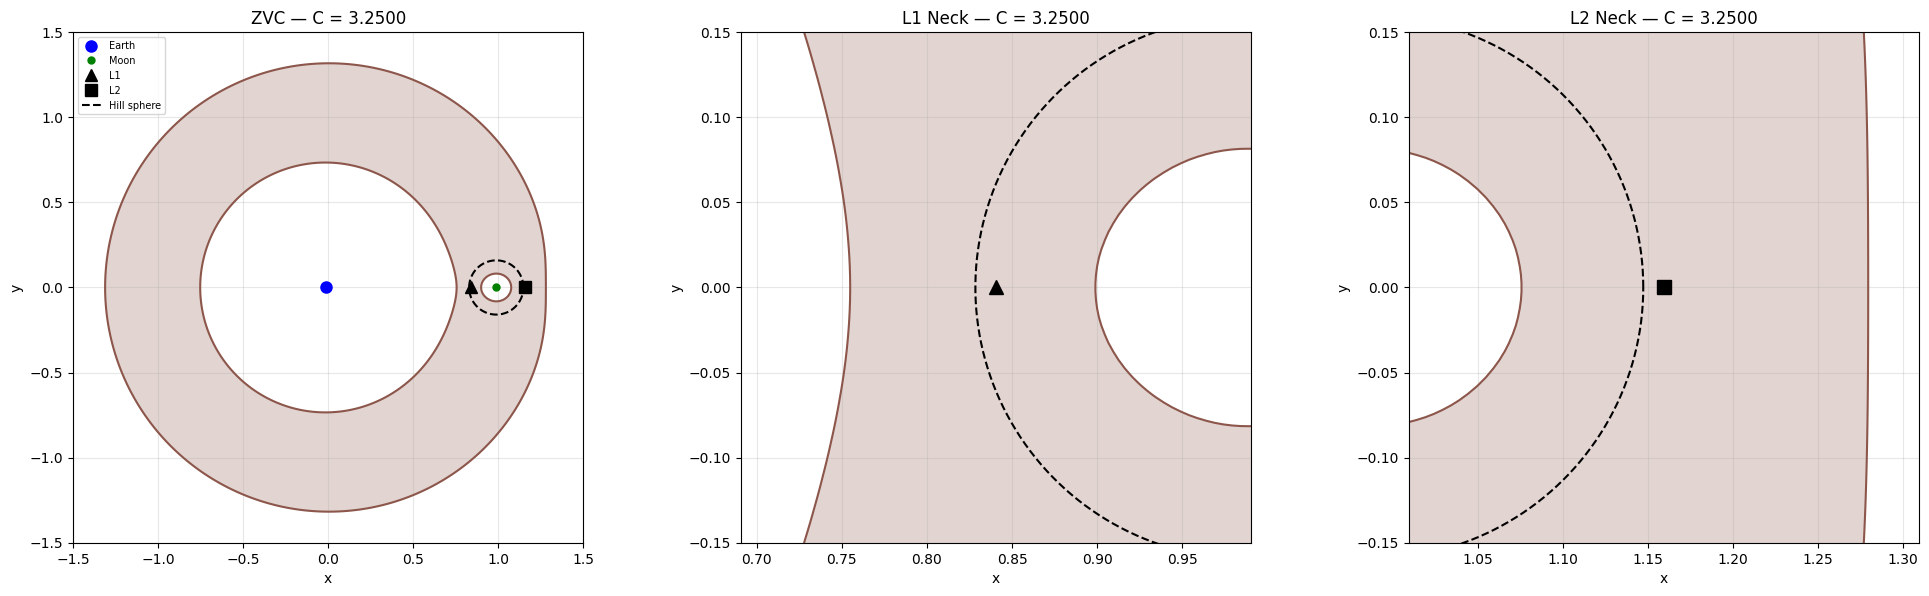

In [5]:
# plot zero velocity curves for various jacobi constants
L1 = np.array([L1_x, 0, 0])
L2 = np.array([L2_x, 0, 0])
jacobi_L1 = calc_Jacobi_constant(np.concatenate((L1, np.zeros(3))), mu)

# build 2D effective potential grid
xg = np.linspace(-1.5, 1.5, 600)
yg = np.linspace(-1.5, 1.5, 600)
Xg, Yg = np.meshgrid(xg, yg)
r1g = np.sqrt((Xg + mu)**2 + Yg**2)
r2g = np.sqrt((Xg - 1 + mu)**2 + Yg**2)
twoU = 2 * ((1 - mu) / r1g + mu / r2g + 0.5 * (Xg**2 + Yg**2))

jacobi_values = [3.10, 3.16, 3.18, jacobi_L1, 3.20, 3.25]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'red', 'tab:purple', 'tab:brown']

r_hill = (mu / 3)**(1/3)
theta = np.linspace(0, 2*np.pi, 200)
jacobi_L2 = calc_Jacobi_constant(np.concatenate((L2, np.zeros(3))), mu)
neck_pad = 0.15  # half-width of zoom window around each Lagrange point

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# --- main plot ---
ax0 = axes[0]
for C, color in zip(jacobi_values[::-1], colors[::-1]):
    ax0.contourf(Xg, Yg, twoU, levels=[twoU.min(), C], colors=[color], alpha=0.15)
for C, color in zip(jacobi_values, colors):
    ax0.contour(Xg, Yg, twoU, levels=[C], colors=[color], linewidths=1.5)
    ax0.plot([], [], color=color, label=f'C = {C:.4f}')
ax0.plot(pos_earth[0], pos_earth[1], 'bo', ms=8, label='Earth')
ax0.plot(pos_moon[0], pos_moon[1], 'go', ms=5, label='Moon')
ax0.plot(L1[0], L1[1], 'k^', ms=8, label=f'L1 (C={jacobi_L1:.4f})')
ax0.plot(L2[0], L2[1], 'ks', ms=8, label=f'L2 (C={jacobi_L2:.4f})')
ax0.plot(pos_moon[0] + r_hill*np.cos(theta), pos_moon[1] + r_hill*np.sin(theta),
         'k--', linewidth=1.5, label=f'Hill sphere (r={r_hill:.4f})')
ax0.set_xlabel('x'); ax0.set_ylabel('y')
ax0.set_title('Zero-Velocity Curves')
ax0.legend(loc='upper left', fontsize=7)
ax0.set_aspect('equal')
ax0.grid(True, alpha=0.3)
ax0.set_xlim(-1.5, 1.5); ax0.set_ylim(-1.5, 1.5)
ax0.set_visible(False)
plt.close(fig)

# --- standalone main plot ---
plt.figure(figsize=(10, 8))
for C, color in zip(jacobi_values[::-1], colors[::-1]):
    plt.contourf(Xg, Yg, twoU, levels=[twoU.min(), C], colors=[color], alpha=0.15)
for C, color in zip(jacobi_values, colors):
    plt.contour(Xg, Yg, twoU, levels=[C], colors=[color], linewidths=1.5)
    plt.plot([], [], color=color, label=f'C = {C:.4f}')
plt.plot(pos_earth[0], pos_earth[1], 'bo', ms=8, label='Earth')
plt.plot(pos_moon[0], pos_moon[1], 'go', ms=5, label='Moon')
plt.plot(L1[0], L1[1], 'k^', ms=8, label=f'L1 (C={jacobi_L1:.4f})')
plt.plot(L2[0], L2[1], 'ks', ms=8, label=f'L2 (C={jacobi_L2:.4f})')
plt.plot(pos_moon[0] + r_hill*np.cos(theta), pos_moon[1] + r_hill*np.sin(theta),
         'k--', linewidth=1.5, label=f'Hill sphere (r={r_hill:.4f})')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Zero-Velocity Curves for Various Jacobi Constants')
plt.legend(loc='upper left')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.xlim(-1.5, 1.5); plt.ylim(-1.5, 1.5)
plt.show()

# --- L1 / L2 neck zoom ---
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
for C, color in zip(jacobi_values[::-1], colors[::-1]):
    ax1.contourf(Xg, Yg, twoU, levels=[twoU.min(), C], colors=[color], alpha=0.15)
for C, color in zip(jacobi_values, colors):
    ax1.contour(Xg, Yg, twoU, levels=[C], colors=[color], linewidths=1.5)
ax1.plot(L1[0], L1[1], 'k^', ms=10)
ax1.plot(pos_moon[0] + r_hill*np.cos(theta), pos_moon[1] + r_hill*np.sin(theta),
         'k--', linewidth=1.5)
ax1.set_xlim(L1_x - neck_pad, L1_x + neck_pad)
ax1.set_ylim(-neck_pad, neck_pad)
ax1.set_aspect('equal')
ax1.set_xlabel('x'); ax1.set_ylabel('y')
ax1.set_title('L1 Neck Region')
ax1.grid(True, alpha=0.3)

# --- L2 neck zoom ---
for C, color in zip(jacobi_values[::-1], colors[::-1]):
    ax2.contourf(Xg, Yg, twoU, levels=[twoU.min(), C], colors=[color], alpha=0.15)
for C, color in zip(jacobi_values, colors):
    ax2.contour(Xg, Yg, twoU, levels=[C], colors=[color], linewidths=1.5)
ax2.plot(L2[0], L2[1], 'ks', ms=10)
ax2.plot(pos_moon[0] + r_hill*np.cos(theta), pos_moon[1] + r_hill*np.sin(theta),
         'k--', linewidth=1.5)
ax2.set_xlim(L2_x - neck_pad, L2_x + neck_pad)
ax2.set_ylim(-neck_pad, neck_pad)
ax2.set_aspect('equal')
ax2.set_xlabel('x'); ax2.set_ylabel('y')
ax2.set_title('L2 Neck Region')
ax2.grid(True, alpha=0.3)
fig2.tight_layout()
plt.show()

# --- separate plot for each C value ---
for C, color in zip(jacobi_values, colors):
    label = f'C = {C:.4f}'
    if np.isclose(C, jacobi_L1):
        label += ' (L1)'

    fig_i, (ax_main, ax_l1, ax_l2) = plt.subplots(1, 3, figsize=(20, 6))

    # full view
    ax_main.contourf(Xg, Yg, twoU, levels=[twoU.min(), C], colors=[color], alpha=0.25)
    ax_main.contour(Xg, Yg, twoU, levels=[C], colors=[color], linewidths=1.5)
    ax_main.plot(pos_earth[0], pos_earth[1], 'bo', ms=8, label='Earth')
    ax_main.plot(pos_moon[0], pos_moon[1], 'go', ms=5, label='Moon')
    ax_main.plot(L1[0], L1[1], 'k^', ms=8, label='L1')
    ax_main.plot(L2[0], L2[1], 'ks', ms=8, label='L2')
    ax_main.plot(pos_moon[0] + r_hill*np.cos(theta), pos_moon[1] + r_hill*np.sin(theta),
                 'k--', linewidth=1.5, label='Hill sphere')
    ax_main.set_xlabel('x'); ax_main.set_ylabel('y')
    ax_main.set_title(f'ZVC — {label}')
    ax_main.legend(loc='upper left', fontsize=7)
    ax_main.set_aspect('equal')
    ax_main.grid(True, alpha=0.3)
    ax_main.set_xlim(-1.5, 1.5); ax_main.set_ylim(-1.5, 1.5)

    # L1 zoom
    ax_l1.contourf(Xg, Yg, twoU, levels=[twoU.min(), C], colors=[color], alpha=0.25)
    ax_l1.contour(Xg, Yg, twoU, levels=[C], colors=[color], linewidths=1.5)
    ax_l1.plot(L1[0], L1[1], 'k^', ms=10)
    ax_l1.plot(pos_moon[0] + r_hill*np.cos(theta), pos_moon[1] + r_hill*np.sin(theta),
               'k--', linewidth=1.5)
    ax_l1.set_xlim(L1_x - neck_pad, L1_x + neck_pad)
    ax_l1.set_ylim(-neck_pad, neck_pad)
    ax_l1.set_aspect('equal')
    ax_l1.set_xlabel('x'); ax_l1.set_ylabel('y')
    ax_l1.set_title(f'L1 Neck — {label}')
    ax_l1.grid(True, alpha=0.3)

    # L2 zoom
    ax_l2.contourf(Xg, Yg, twoU, levels=[twoU.min(), C], colors=[color], alpha=0.25)
    ax_l2.contour(Xg, Yg, twoU, levels=[C], colors=[color], linewidths=1.5)
    ax_l2.plot(L2[0], L2[1], 'ks', ms=10)
    ax_l2.plot(pos_moon[0] + r_hill*np.cos(theta), pos_moon[1] + r_hill*np.sin(theta),
               'k--', linewidth=1.5)
    ax_l2.set_xlim(L2_x - neck_pad, L2_x + neck_pad)
    ax_l2.set_ylim(-neck_pad, neck_pad)
    ax_l2.set_aspect('equal')
    ax_l2.set_xlabel('x'); ax_l2.set_ylabel('y')
    ax_l2.set_title(f'L2 Neck — {label}')
    ax_l2.grid(True, alpha=0.3)

    fig_i.tight_layout()
    plt.show()




1.2 Define Capture Metrics (Critical)
Choose objective, computable criteria.
Minimum recommended:

Particle inside Moon's Hill sphere 
Moon‑relative Kepler energy < 0 
Residence time T>TminT > T_{min} (e.g., multiple moon revolutions) 

Deliverable

Formal capture definition 
Flowchart for trajectory classification: Fly‑by 
Temporary capture 
Impact 
Escape 


C_J(L1) = 3.188533
C_J(L2) = 3.172292
Target C_J = 3.180413
IC: x0=0.8206, vy0=0.103945, CJ_actual=3.180413
Capture windows found : 1
Longest capture       : t=[59.35, 68.67]  duration=9.32
Lunar peri-apse passes: 7


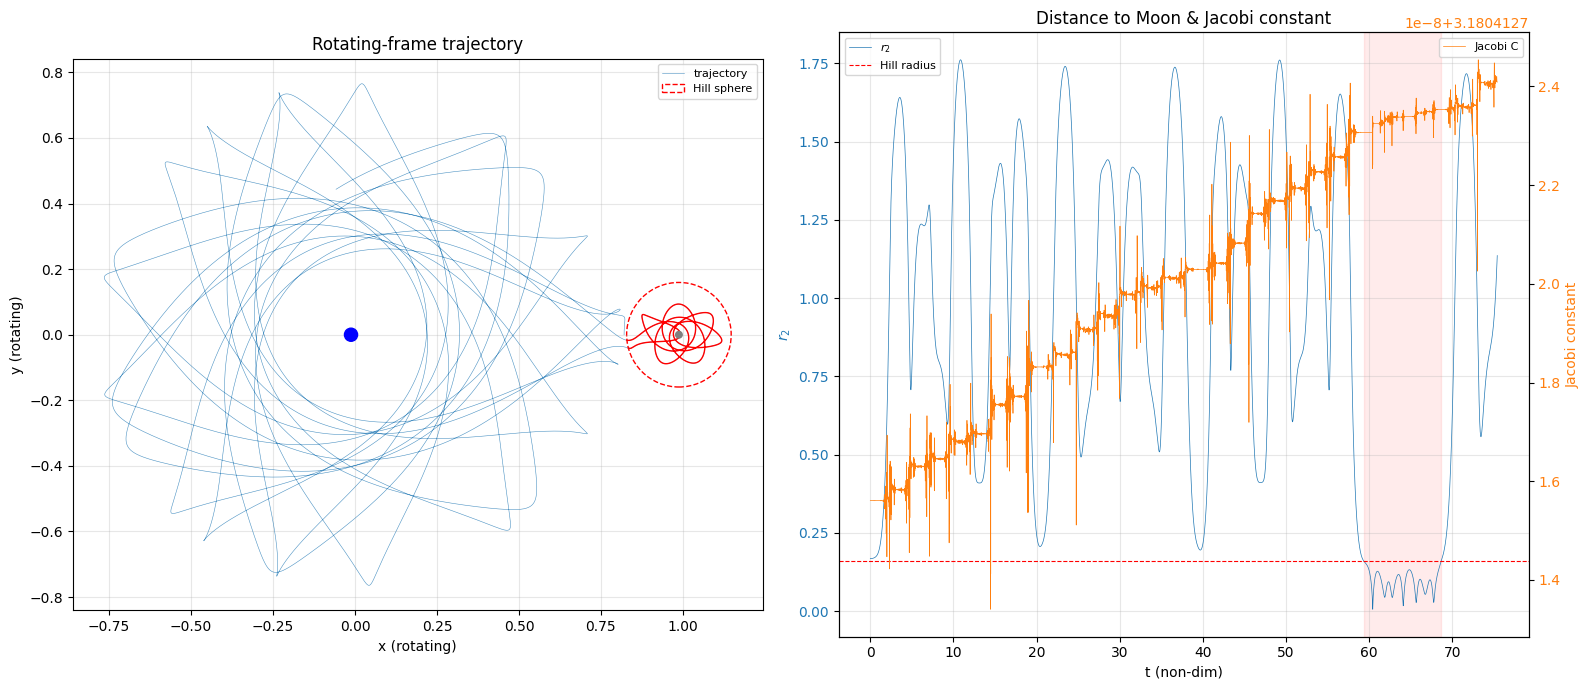

In [31]:
from scipy.signal import argrelmin
from matplotlib.patches import Circle

# ── Simulation parameters ──────────────────────────────────────────
masses = np.array([1 - mu, mu, 1e-20])
t_span = (0, 12 * 2 * np.pi)  # 12 lunar orbits
dt = 0.001

# ── Compute Jacobi constants at L1 and L2 ──────────────────────────
CJ_L1 = calc_Jacobi_constant(np.array([L1_x, 0, 0, 0, 0, 0]), mu)
CJ_L2 = calc_Jacobi_constant(np.array([L2_x, 0, 0, 0, 0, 0]), mu)
print(f"C_J(L1) = {CJ_L1:.6f}")
print(f"C_J(L2) = {CJ_L2:.6f}")

# Target CJ midway between L1 and L2 (L1 neck open, L2 neck closed)
CJ_target = 0.5 * (CJ_L1 + CJ_L2)
print(f"Target C_J = {CJ_target:.6f}")

# Initial position: just inside L1 neck, approaching Moon
x0 = L1_x - 0.02
y0, z0 = 0.0, 0.0
vx0, vz0 = 0.0, 0.0

# Solve for vy from Jacobi constant: CJ = 2*U - v^2 => v = sqrt(2U - CJ)
U0 = effective_potential(G, mu, pos_earth, pos_moon, np.array([x0, y0, z0]))
vy_sq = 2 * U0 - CJ_target
if vy_sq < 0:
    raise ValueError(f"Cannot achieve CJ={CJ_target:.4f} at x={x0:.4f} (2U={2*U0:.4f})")
vy0 = np.sqrt(vy_sq)
initial_state = [x0, y0, z0, vx0, vy0, vz0]
CJ_check = calc_Jacobi_constant(np.array(initial_state), mu)
print(f"IC: x0={x0:.4f}, vy0={vy0:.6f}, CJ_actual={CJ_check:.6f}")

# ── Integrate & analyse ────────────────────────────────────────────
t, x, y, z, vx, vy, vz, jacobi = trajectory_analysis(
    mu, masses, initial_state, t_span, dt
)

# distance to Moon at each step
r_moon = np.sqrt((x - pos_moon[0])**2 + y**2 + z**2)

# capture flag per step
captured = np.array([
    is_captured(np.array([x[i], y[i], z[i], vx[i], vy[i], vz[i]]),
                mu, hill_radius)
    for i in range(len(t))
])

# ── Identify capture / escape epochs ──────────────────────────────
capture_starts = []
capture_ends = []
in_capture = False
for i in range(len(captured)):
    if captured[i] and not in_capture:
        capture_starts.append(i)
        in_capture = True
    elif not captured[i] and in_capture:
        capture_ends.append(i)
        in_capture = False
if in_capture:
    capture_ends.append(len(captured) - 1)

# count lunar orbits inside longest capture window
if capture_starts:
    lens = [capture_ends[j] - capture_starts[j] for j in range(len(capture_starts))]
    best = int(np.argmax(lens))
    i_s, i_e = capture_starts[best], capture_ends[best]
    r_seg = r_moon[i_s:i_e]
    local_min_idx = argrelmin(r_seg, order=5)[0]
    n_orbits = len(local_min_idx)
    capture_duration = t[i_e] - t[i_s]
else:
    n_orbits = 0
    capture_duration = 0.0

print(f"Capture windows found : {len(capture_starts)}")
if capture_starts:
    print(f"Longest capture       : t=[{t[i_s]:.2f}, {t[i_e]:.2f}]  "
          f"duration={capture_duration:.2f}")
    print(f"Lunar peri-apse passes: {n_orbits}")
else:
    print("No capture detected — particle did not enter Hill sphere")

# ── Figure 1: rotating-frame trajectory ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
ax.set_title("Rotating-frame trajectory")
ax.plot(x, y, linewidth=0.4, alpha=0.8, label="trajectory")
ax.add_patch(Circle(pos_earth[:2], 0.02, color='blue', zorder=5))
ax.add_patch(Circle(pos_moon[:2],  0.01, color='gray', zorder=5))
circle_hill = Circle(pos_moon[:2], hill_radius, fill=False,
                     linestyle='--', color='red', label='Hill sphere')
ax.add_patch(circle_hill)
ax.set_xlabel("x (rotating)")
ax.set_ylabel("y (rotating)")
ax.set_aspect('equal')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# highlight captured arcs
for j in range(len(capture_starts)):
    s, e = capture_starts[j], capture_ends[j]
    ax.plot(x[s:e], y[s:e], color='red', linewidth=1.0)

# ── Figure 2: distance to Moon & Jacobi constant ──────────────────
ax2 = axes[1]
color1, color2 = 'tab:blue', 'tab:orange'
ax2.set_title("Distance to Moon & Jacobi constant")
ax2.plot(t, r_moon, color=color1, linewidth=0.5, label=r"$r_2$")
ax2.axhline(hill_radius, color='red', linestyle='--', linewidth=0.8,
            label="Hill radius")
ax2.set_xlabel("t (non-dim)")
ax2.set_ylabel(r"$r_2$", color=color1)
ax2.tick_params(axis='y', labelcolor=color1)
ax2.legend(loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.3)

ax3 = ax2.twinx()
ax3.plot(t, jacobi, color=color2, linewidth=0.5, label="Jacobi C")
ax3.set_ylabel("Jacobi constant", color=color2)
ax3.tick_params(axis='y', labelcolor=color2)
ax3.legend(loc='upper right', fontsize=8)

# shade captured intervals
for j in range(len(capture_starts)):
    s, e = capture_starts[j], capture_ends[j]
    ax2.axvspan(t[s], t[e], color='red', alpha=0.08)

plt.tight_layout()
plt.show()



Phase 2 — Phase‑Space Geometry
Goal: Show you understand why capture occurs.
2.1 L1/L2 Structure

Compute collinear Lagrange points 
Plot ZVCs near neck opening 
Identify energy threshold for Earth access 
Deliverable

ZVC plots showing capture‑accessible regimes 
Explanation of neck dynamics 


Jacobi levelPhase‑space geometryC>CL1C > C_{L1}C>CL1​Moon region isolatedC=CL1C = C_{L1}C=CL1​Bottleneck (neck) opensC<CL1C < C_{L1}C<CL1​Transit between Earth ↔ Moon possible



C(L1) = 3.188533
C(L2) = 3.172292
C(trajectory, t=0) = 3.180413


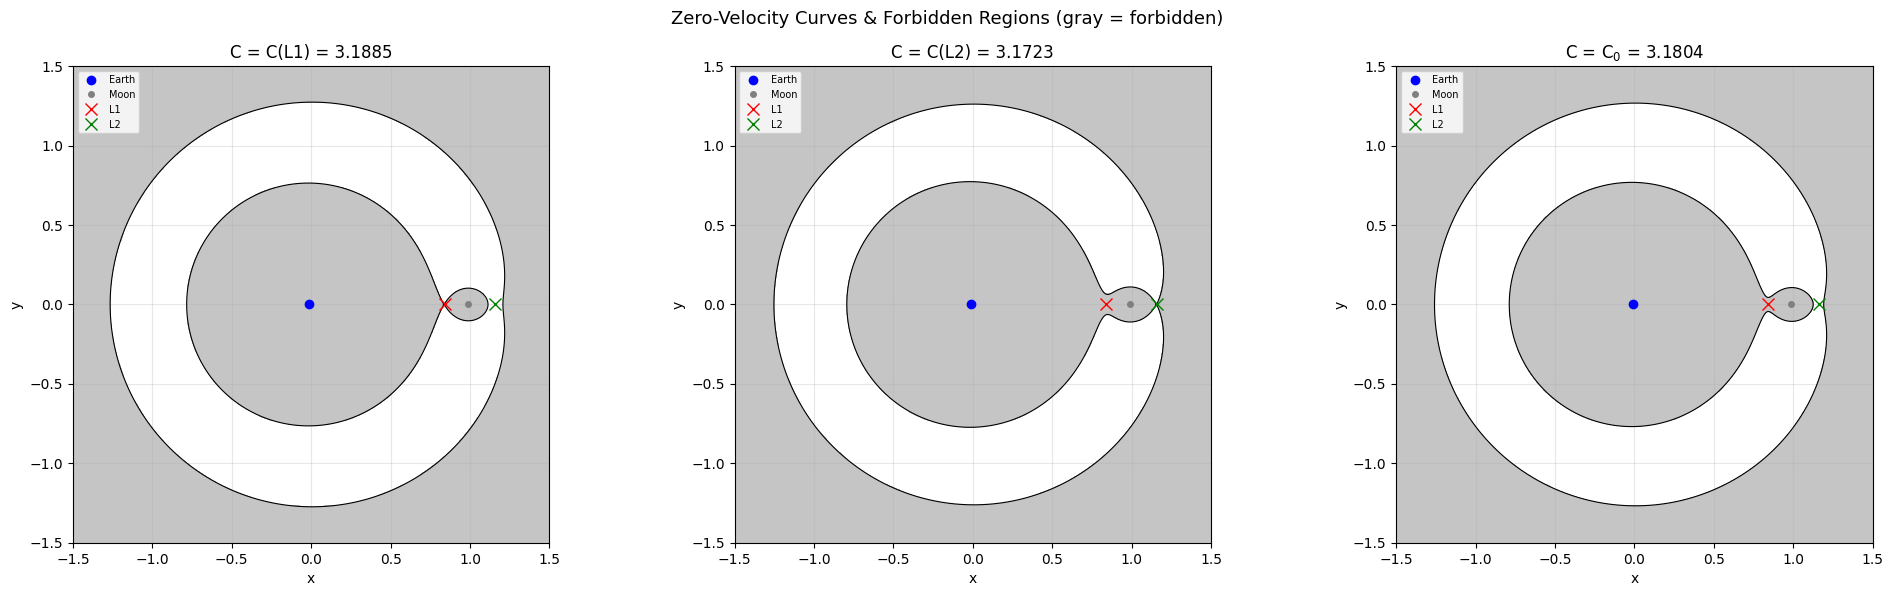

In [32]:
# ── Phase-space geometry: ZVCs, forbidden regions, energy surfaces ──

# Jacobi constant of L1 and L2
C_L1 = calc_Jacobi_constant(np.array([L1_x, 0, 0, 0, 0, 0]), mu)
C_L2 = calc_Jacobi_constant(np.array([L2_x, 0, 0, 0, 0, 0]), mu)
print(f"C(L1) = {C_L1:.6f}")
print(f"C(L2) = {C_L2:.6f}")

# Jacobi constant of the test trajectory at t = 0
C0 = jacobi[0]
print(f"C(trajectory, t=0) = {C0:.6f}")

# ── Grid for effective potential ───────────────────────────────────
N = 500
xg = np.linspace(-1.5, 1.5, N)
yg = np.linspace(-1.5, 1.5, N)
Xg, Yg = np.meshgrid(xg, yg)
U_grid = np.zeros_like(Xg)
for i in range(N):
    for j in range(N):
        U_grid[i, j] = effective_potential(
            G, mu, pos_earth, pos_moon,
            np.array([Xg[i, j], Yg[i, j], 0.0])
        )

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (C_val, label) in enumerate([
    (C_L1, f"C = C(L1) = {C_L1:.4f}"),
    (C_L2, f"C = C(L2) = {C_L2:.4f}"),
    (C0,   f"C = C$_0$ = {C0:.4f}")
]):
    ax = axes[idx]
    # forbidden region: 2U > C  →  allowed when 2U - C < 0
    forbidden = (2 * U_grid - C_val) > 0
    ax.contourf(Xg, Yg, forbidden.astype(float),
                levels=[0.5, 1.5], colors=['gray'], alpha=0.45)
    ax.contour(Xg, Yg, 2 * U_grid, levels=[C_val],
               colors='black', linewidths=0.8)
    ax.plot(*pos_earth[:2], 'bo', ms=6, label='Earth')
    ax.plot(*pos_moon[:2],  'o', color='gray', ms=4, label='Moon')
    ax.plot(L1_x, 0, 'rx', ms=8, label='L1')
    ax.plot(L2_x, 0, 'gx', ms=8, label='L2')
    ax.set_title(label)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(True, alpha=0.3)

plt.suptitle("Zero-Velocity Curves & Forbidden Regions (gray = forbidden)",
             fontsize=13)
plt.tight_layout()
plt.show()




 2.2 Periodic Orbits & Manifolds (Core Non‑Trivial Element)

Compute planar Lyapunov orbits about L1 and/or L2 
Linearize → monodromy matrix 
Generate stable and unstable manifolds 
Deliverable

Manifold tubes in configuration space 
Short explanation of transport mechanism 

This is where your project crosses from “numerical experiment” to celestial mechanics.




L1: found 8 periodic orbits
L2: found 7 periodic orbits


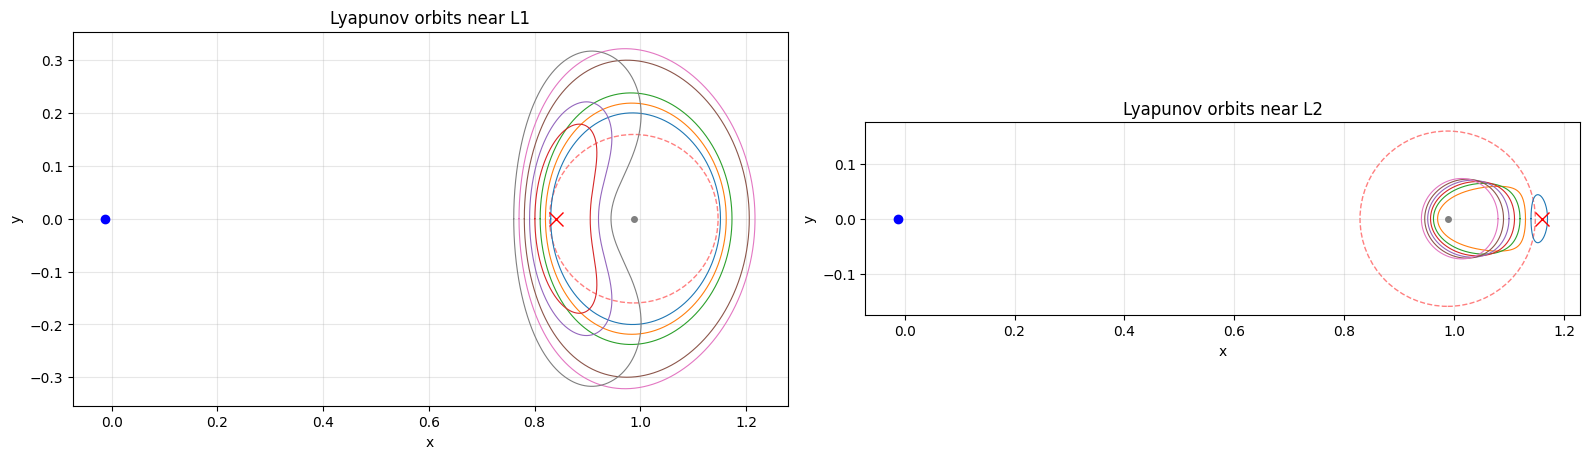


Stability analysis (monodromy eigenvalues):

  L1 family:
    orbit 0: T=2.7012  stability index=1.0000  |lambda_max|=1.0000
    orbit 1: T=2.9065  stability index=1.0000  |lambda_max|=1.0000
    orbit 2: T=3.1083  stability index=1.0000  |lambda_max|=1.0000
    orbit 3: T=3.3016  stability index=423.1075  |lambda_max|=846.2137
    orbit 4: T=3.6530  stability index=271.6923  |lambda_max|=543.3828
    orbit 5: T=3.6812  stability index=1.0000  |lambda_max|=1.0000
    orbit 6: T=3.8581  stability index=1.0000  |lambda_max|=1.0001
    orbit 7: T=4.5590  stability index=121.5759  |lambda_max|=243.1478

  L2 family:
    orbit 0: T=3.3829  stability index=695.3754  |lambda_max|=1390.7501
    orbit 1: T=2.6930  stability index=2.0470  |lambda_max|=3.8332
    orbit 2: T=2.1601  stability index=1.0000  |lambda_max|=1.0000
    orbit 3: T=1.8760  stability index=1.0000  |lambda_max|=1.0000
    orbit 4: T=1.6780  stability index=1.0000  |lambda_max|=1.0000
    orbit 5: T=1.5314  stability index=

In [33]:
from matplotlib.patches import Circle
masses = np.array([1 - mu, mu, 1e-20])

# Compute planar Lyapunov orbits about L1 and/or L2 and analyze their stability properties.

def state_transition_matrix(t, Y, mu, masses):
    """4x4 linearized variational equations appended to the state."""
    state = Y[:6]
    Phi = Y[6:].reshape((6, 6))

    x, y, z, vx, vy, vz = state
    r1 = np.sqrt((x + mu)**2 + y**2 + z**2)
    r2 = np.sqrt((x - 1 + mu)**2 + y**2 + z**2)

    Uxx = 1 - (1-mu)/r1**3 - mu/r2**3 \
          + 3*(1-mu)*(x+mu)**2/r1**5 + 3*mu*(x-1+mu)**2/r2**5
    Uyy = 1 - (1-mu)/r1**3 - mu/r2**3 \
          + 3*(1-mu)*y**2/r1**5 + 3*mu*y**2/r2**5
    Uzz = -(1-mu)/r1**3 - mu/r2**3 \
          + 3*(1-mu)*z**2/r1**5 + 3*mu*z**2/r2**5
    Uxy = 3*(1-mu)*(x+mu)*y/r1**5 + 3*mu*(x-1+mu)*y/r2**5
    Uxz = 3*(1-mu)*(x+mu)*z/r1**5 + 3*mu*(x-1+mu)*z/r2**5
    Uyz = 3*(1-mu)*y*z/r1**5 + 3*mu*y*z/r2**5

    A = np.array([
        [0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 1],
        [Uxx, Uxy, Uxz, 0,  2, 0],
        [Uxy, Uyy, Uyz, -2, 0, 0],
        [Uxz, Uyz, Uzz, 0,  0, 0],
    ])

    dstate = np.array(equations_of_motion(t, state, mu, masses))
    dPhi = (A @ Phi).flatten()
    return np.concatenate([dstate, dPhi])

def shooting_lyapunov(mu, masses, Lx, dx, tol=1e-10, max_iter=50):
    """Differential-correction shooter for a planar Lyapunov orbit.
    dx = offset from Lagrange point along x-axis.
    Returns (state0, period) for the symmetric periodic orbit."""
    x0 = Lx + dx

    # Estimate initial vy from linearized dynamics near Lx
    r1 = abs(x0 - (-mu));  r2 = abs(x0 - (1 - mu))
    Uxx = 1 - (1-mu)/r1**3 - mu/r2**3 + 3*(1-mu)*(x0+mu)**2/r1**5 + 3*mu*(x0-1+mu)**2/r2**5
    # vy \approx |dx| * sqrt(|Uxx|) if Uxx < 0 (which it is near L1/L2)
    vy0 = -abs(dx) * np.sqrt(abs(Uxx)) if Uxx < 0 else -0.01 * abs(dx)

    for iteration in range(max_iter):
        state0 = np.array([x0, 0.0, 0.0, 0.0, vy0, 0.0])
        Phi0 = np.eye(6).flatten()
        Y0 = np.concatenate([state0, Phi0])

        def y_cross(t, Y, mu, masses):
            return Y[1]
        y_cross.terminal = True
        y_cross.direction = -1

        sol = solve_ivp(state_transition_matrix,
                        (0, 20), Y0, args=(mu, masses),
                        events=y_cross, rtol=1e-12, atol=1e-14,
                        method='DOP853', max_step=0.005,
                        dense_output=True)

        if len(sol.t_events[0]) == 0:
            raise RuntimeError("No y=0 crossing found")

        t_half = sol.t_events[0][0]
        if t_half < 1e-10:
            # Event fired at t=0; flip vy sign
            vy0 = -vy0
            continue

        Y_half = sol.y_events[0][0]
        state_half = Y_half[:6]
        Phi_half = Y_half[6:].reshape((6, 6))

        vx_half = state_half[3]
        if abs(vx_half) < tol:
            period = 2 * t_half
            return state0, period

        f_half = np.array(equations_of_motion(t_half, state_half, mu, masses))
        vy_half = state_half[4]
        if abs(vy_half) < 1e-15:
            raise RuntimeError("vy at half-period is zero")

        dvx_dvy0 = Phi_half[3, 4] - f_half[3] * Phi_half[1, 4] / vy_half
        if abs(dvx_dvy0) < 1e-14:
            raise RuntimeError("Singular correction matrix")
        vy0 -= vx_half / dvx_dvy0

    raise RuntimeError("Shooter did not converge")

# ── Compute Lyapunov family for L1 and L2 ─────────────────────────
results = {}
for name, Lx in [("L1", L1_x), ("L2", L2_x)]:
    dx_offsets = np.linspace(0.01, 0.08, 8)
    family = []
    for dx in dx_offsets:
        try:
            # Try both dx signs to handle different Lagrange point geometries
            try:
                s0, T = shooting_lyapunov(mu, masses, Lx, -dx)
            except RuntimeError:
                s0, T = shooting_lyapunov(mu, masses, Lx, dx)
            family.append((s0.copy(), T))
        except RuntimeError:
            continue
    results[name] = family
    print(f"{name}: found {len(family)} periodic orbits")

# ── Plot Lyapunov families ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for idx, name in enumerate(["L1", "L2"]):
    ax = axes[idx]
    ax.set_title(f"Lyapunov orbits near {name}")
    Lx_val = L1_x if name == "L1" else L2_x
    for s0, T in results[name]:
        if T <= 0 or not np.isfinite(T):
            continue
        n_pts = max(500, int(round(2000 * T / 6.0)))
        t_eval = np.linspace(0, T, n_pts)
        sol = solve_ivp(equations_of_motion, (0, T), s0,
                        args=(mu, masses), t_eval=t_eval,
                        method='DOP853', rtol=1e-10, atol=1e-12)
        ax.plot(sol.y[0], sol.y[1], linewidth=0.8)
    ax.plot(*pos_earth[:2], 'bo', ms=6)
    ax.plot(*pos_moon[:2], 'o', color='gray', ms=4)
    ax.plot(Lx_val, 0, 'rx', ms=10)
    circle_h = Circle(pos_moon[:2], hill_radius, fill=False,
                      linestyle='--', color='red', alpha=0.5)
    ax.add_patch(circle_h)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Monodromy matrix & stability indices ───────────────────────────
print("\nStability analysis (monodromy eigenvalues):")
for name in ["L1", "L2"]:
    print(f"\n  {name} family:")
    for k, (s0, T) in enumerate(results[name]):
        if T <= 0 or not np.isfinite(T):
            print(f"    orbit {k}: skipped (invalid T={T})")
            continue
        Phi0 = np.eye(6).flatten()
        Y0 = np.concatenate([s0, Phi0])
        sol = solve_ivp(state_transition_matrix,
                        (0, T), Y0, args=(mu, masses),
                        rtol=1e-12, atol=1e-14,
                        method='DOP853', max_step=T / 2000)
        Phi_T = sol.y[6:, -1].reshape((6, 6))
        evals = np.linalg.eigvals(Phi_T)
        si = 0.5 * np.abs(evals[np.argmax(np.abs(evals))]
                          + 1.0 / evals[np.argmax(np.abs(evals))])
        print(f"    orbit {k}: T={T:.4f}  stability index={si.real:.4f}  "
              f"|lambda_max|={np.max(np.abs(evals)):.4f}")



2.3 Invariant Manifolds of Lyapunov Orbits

Compute the stable ($W^s$) and unstable ($W^u$) manifolds
of the L1 and L2 Lyapunov orbits found above.

* Perturb along the eigenvectors of the monodromy matrix
* Integrate forward (unstable) and backward (stable)
* Overlay on the ZVC plot to visualise transport corridors


In [ ]:
# ── Invariant manifolds of Lyapunov orbits ──────────────────────────

def compute_manifold(mu, masses, s0, T, n_pts=40, eps=1e-6,
                     t_man=6.0, dt_man=0.005, direction=1):
    """Compute one branch of the invariant manifold.
    direction = +1  → unstable (integrate forward)
    direction = -1  → stable   (integrate backward)
    Returns list of (t_arr, x_arr, y_arr) for each departure point.
    """
    Phi0 = np.eye(6).flatten()
    Y0 = np.concatenate([s0, Phi0])
    sol_full = solve_ivp(state_transition_matrix,
                         (0, T), Y0, args=(mu, masses),
                         rtol=1e-12, atol=1e-14,
                         method='DOP853', max_step=T / 2000,
                         dense_output=True)

    Phi_T = sol_full.y[6:, -1].reshape((6, 6))
    evals, evecs = np.linalg.eig(Phi_T)

    if direction == 1:
        idx_eig = np.argmax(np.abs(evals))
    else:
        idx_eig = np.argmin(np.abs(evals))
    v_eig = np.real(evecs[:, idx_eig])
    v_eig = v_eig / np.linalg.norm(v_eig)

    trajectories = []
    for k in range(n_pts):
        tau = k * T / n_pts
        Y_tau = sol_full.sol(tau)
        Phi_tau = Y_tau[6:].reshape((6, 6))
        v_local = Phi_tau @ v_eig
        v_local = v_local / np.linalg.norm(v_local)

        for sign in [+1, -1]:
            s_dep = Y_tau[:6] + sign * eps * v_local
            if direction == 1:
                span = (0, t_man)
            else:
                span = (0, -t_man)
            sol_m = solve_ivp(equations_of_motion, span, s_dep,
                              args=(mu, masses), rtol=1e-10, atol=1e-12,
                              method='DOP853', max_step=dt_man)
            trajectories.append((sol_m.t, sol_m.y[0], sol_m.y[1]))
    return trajectories

# ── Compute manifolds for the largest L1 and L2 orbit ──────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for idx, name in enumerate(["L1", "L2"]):
    ax = axes[idx]
    if not results[name]:
        ax.set_title(f"{name}: no orbit found")
        continue

    s0, T = results[name][-1]

    # unstable manifold (forward)
    Wu = compute_manifold(mu, masses, s0, T, direction=1, t_man=4.0)
    for (tm, xm, ym) in Wu:
        ax.plot(xm, ym, color='red', linewidth=0.3, alpha=0.5)

    # stable manifold (backward)
    Ws = compute_manifold(mu, masses, s0, T, direction=-1, t_man=4.0)
    for (tm, xm, ym) in Ws:
        ax.plot(xm, ym, color='blue', linewidth=0.3, alpha=0.5)

    # plot the orbit itself
    t_orb, xo, yo, zo, _, _, _ = integrate_orbits(
        mu, masses, s0.tolist(), (0, T), T / 2000
    )
    ax.plot(xo, yo, 'k-', linewidth=1.5, label='Lyapunov orbit')

    ax.plot(*pos_earth[:2], 'bo', ms=6)
    ax.plot(*pos_moon[:2], 'o', color='gray', ms=4)
    lx = L1_x if name == "L1" else L2_x
    ax.plot(lx, 0, 'gx', ms=10)
    ch = Circle(pos_moon[:2], hill_radius, fill=False,
                linestyle='--', color='green', alpha=0.5)
    ax.add_patch(ch)
    ax.set_title(f"{name} manifolds (red=W$^u$, blue=W$^s$)")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_xlim(0.6, 1.25); ax.set_ylim(-0.25, 0.25)
    ax.set_aspect('equal')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



Phase 3 — Capture Experiments
Goal: Connect manifolds to actual captured trajectories.
3.1 Energy Sweep Experiment

Sample initial conditions on a Poincaré section 
Sweep Jacobi constant near L1/L2 opening 
Track capture probability 
Deliverables

Capture probability vs CC 
Phase‑space slices with capture regions highlighted 



3.2 Monte‑Carlo Injection

Inject particles near L1/L2 region 
Integrate forward in time 
Classify outcomes 
Deliverables

Outcome maps 
Residence‑time histograms 
Example long‑lived capture trajectories 



3.3 Manifold Overlay (Key Insight)

Overlay captured trajectories on invariant manifolds 
Demonstrate that long‑lived captures shadow stable manifolds 
Deliverable

Single figure showing manifolds + capture trajectories 
This figure often becomes the centerpiece of the project 



Phase 4 — Sensitivity & Chaos
Goal: Show understanding of instability and transient nature.

Perturb initial conditions slightly 
Measure variation in capture time 
Identify chaotic sensitivity near separatrices 
Deliverables

ΔIC vs Δcapture‑time plot 
Short discussion of chaotic transport 



Phase 6 — Synthesis & Interpretation
Goal: Demonstrate understanding, not just results.
You should be able to answer:

Why capture is rare 
Why it is temporary 
Why manifolds matter 
Why duration varies wildly 
Deliverables

Final discussion section 
Physical interpretation in plain language 



Final Report Structure (Suggested)

Introduction & Motivation 
Dynamical Model 
Capture Definition 
Phase‑Space Geometry 
Numerical Experiments 
Results 
Physical Interpretation 
Limitations & Extensions 
